In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('Ice_cream selling data.csv')

In [3]:
data.head(5)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [5]:
data.isna().sum()


Temperature (°C)           0
Ice Cream Sales (units)    0
dtype: int64

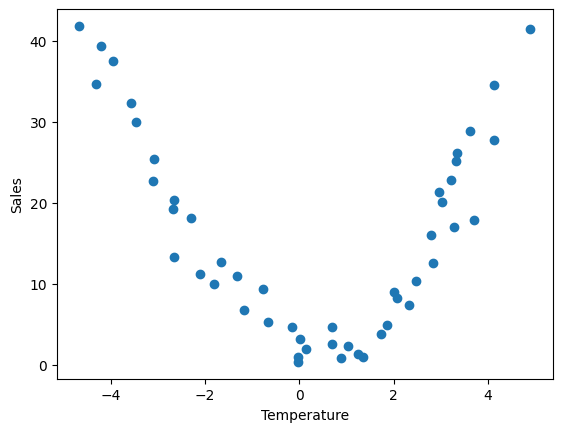

In [6]:
import matplotlib.pyplot as plt

plt.scatter(data['Temperature (°C)'], data['Ice Cream Sales (units)'])
plt.xlabel("Temperature")
plt.ylabel("Sales")
plt.show()

In [10]:
X = data[['Temperature (°C)']]
y = data['Ice Cream Sales (units)']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.linear_model import LinearRegression

l = LinearRegression()
l.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
from sklearn.metrics import r2_score
y_pred_l = lin.predict(X_test)
print( r2_score(y_test, y_pred_l))

-0.5751270190188227


In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly2 = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly2.fit(X_train, y_train)

y_pred_2 = poly2.predict(X_test)
print(r2_score(y_test, y_pred_2))

0.843055137193884


In [20]:
poly3 = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly3.fit(X_train, y_train)

y_pred_3 = poly3.predict(X_test)
print(r2_score(y_test, y_pred_3))

0.8405107685716915
